<a href="https://colab.research.google.com/github/f3r21/actas-cnn/blob/main/notebooks/pipeline_demo_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# actas-cnn — pipeline didactico end-to-end (Colab GPU)

Version del notebook didactico (`pipeline_demo.ipynb`) adaptada para
Google Colab / Kaggle con GPU. Recorre el pipeline completo paso a
paso con visualizaciones:

1. PDF original (escaneo ONPE) -> PNG renderizado a 200 dpi.
2. Deteccion de 15 fiducial markers para registracion afin.
3. Recorte por plantilla calibrada en 42 campos.
4. Subdivision de cada campo en 3-4 celdas.
5. Filtrado de celdas vacias por convencion right-justified ONPE.
6. Manifest CSV.
7. Entrenamiento de ResNet-18 estilo CIFAR (20 epochs, GPU).
8. Evaluacion downstream: digit / field / acta-level + reconstruccion.
9. Matriz de confusion + ranking de actas peor reconstruidas.

**Como correr**:
1. `Runtime` → `Change runtime type` → **T4 GPU** (plan gratis).
2. `Runtime` → `Run all`. **No requiere tokens**: dataset publico en HF.
3. Tiempo total esperado: ~10-15 min en T4 (~35 min en MPS local).

Al final, el navegador descarga el checkpoint `.pt` y el CSV de
metricas. Movelos a tu repo local en `checkpoints/` y `data/`.

**Metricas oficiales esperadas** (val set, 693 actas, 29,106 campos):

| Metrica | Valor |
|---|---|
| Digit-level accuracy | ~98.12% |
| Field-level accuracy | ~98.87% |
| Acta-level accuracy | ~90.33% |
| Reconstruccion exacta del total | ~93.80% |

## Setup Colab (3 celdas)

In [1]:
# 1. Clonar el repo
import os, sys
REPO_URL = 'https://github.com/f3r21/actas-cnn.git'
REPO_DIR = 'actas-cnn'
if not os.path.isdir(REPO_DIR):
    os.system(f'git clone {REPO_URL}')
os.chdir(REPO_DIR)
sys.path.insert(0, os.getcwd())
print('cwd:', os.getcwd())

cwd: /content/actas-cnn


In [2]:
# 2. Instalar dependencias (torch ya viene en Colab/Kaggle con CUDA)
os.system('pip install -q -r requirements.txt')

0

In [3]:
# 3. Descargar el bundle de datos (~460 MB) desde HF (publico, sin token)
from huggingface_hub import hf_hub_download
from config import REMOTE

bundle = hf_hub_download(
    repo_id=REMOTE.hf_dataset_repo,
    repo_type='dataset',
    filename='data_bundle.tar.gz',
)
print(f'bundle bajado: {bundle}')
os.system(f'tar -xzf {bundle} -C .')
print('descomprimido')
os.system('ls -lh data/ | head; echo; ls data/crops_train/ | head -3')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data_bundle.tar.gz:   0%|          | 0.00/481M [00:00<?, ?B/s]

bundle bajado: /root/.cache/huggingface/hub/datasets--f3r21--actas-cnn-dataset/snapshots/f89b681983f1d3426c64637143fe0fef60bf2c0e/data_bundle.tar.gz
descomprimido


0

In [4]:
# 4. Setup paths + imports + verificar GPU
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import fitz  # PyMuPDF
import torch

from extract_crops import crop_fields, split_digits, es_celda_escrita, load_templates
from scripts.detect_fiducials import detect_15, load_anchors, transform_template
from scripts.build_crops import int_to_digits, field_value_for
from model import build_model
from dataset import default_transforms
from env import torch_device

REPO = Path.cwd()
ARCHIVO_ID = '69e09e9dd7b6147f63eafd1c'
PDF_PATH = REPO / 'sample_data' / 'sample_acta.pdf'
PNG_PATH = REPO / 'sample_data' / 'sample_acta.png'
TEMPLATE = load_templates(REPO / 'templates.json')['presidencial']
ANCHORS = load_anchors(REPO / 'fiducial_anchors.json')

device = torch_device()
print(f'device: {device}')
print(f'archivoId: {ARCHIVO_ID}')
print(f'template: {len(TEMPLATE["fields"])} campos | anchors: {len(ANCHORS)} roles')

device: cuda
archivoId: 69e09e9dd7b6147f63eafd1c
template: 42 campos | anchors: 15 roles


## Paso 1: PDF -> PNG

Cada acta ONPE viene como PDF escaneado. La renderizamos a PNG de
2339 × 3309 px (200 dpi sobre A4). Si la pagina viene en landscape se
rota 90° para normalizar la orientacion.

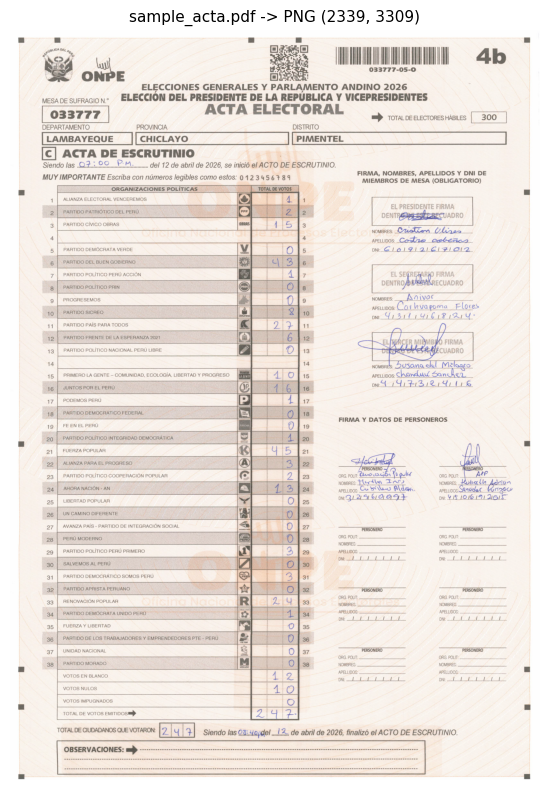

In [5]:
DPI = 200
TARGET_W, TARGET_H = 2339, 3309

doc = fitz.open(PDF_PATH)
pix = doc[0].get_pixmap(matrix=fitz.Matrix(DPI / 72, DPI / 72), alpha=False)
img = Image.frombytes('RGB', (pix.width, pix.height), pix.samples)
if img.width > img.height:
    img = img.rotate(-90, expand=True)
img = img.resize((TARGET_W, TARGET_H), Image.LANCZOS)
img.save(PNG_PATH)
doc.close()

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(img, cmap='gray')
ax.set_title(f'sample_acta.pdf -> PNG {img.size}', fontsize=11)
ax.axis('off')
plt.tight_layout(); plt.show()

## Paso 2: Deteccion de 15 fiducial markers

ONPE imprime 15 cuadraditos negros en el perimetro:
- 4 esquinas (TL, TR, BL, BR)
- 3 en el margen superior (T1, T2, T3)
- 4 en el margen izquierdo (L1..L4)
- 4 en el margen derecho (R1..R4)

El detector zonal escanea 4 regiones, encuentra blobs cuadrados oscuros
y los ordena por posicion para asignar el rol. Despues se computa una
transformacion afin que alinea el acta al espacio canonico de la plantilla.

detectados: 15/15 markers


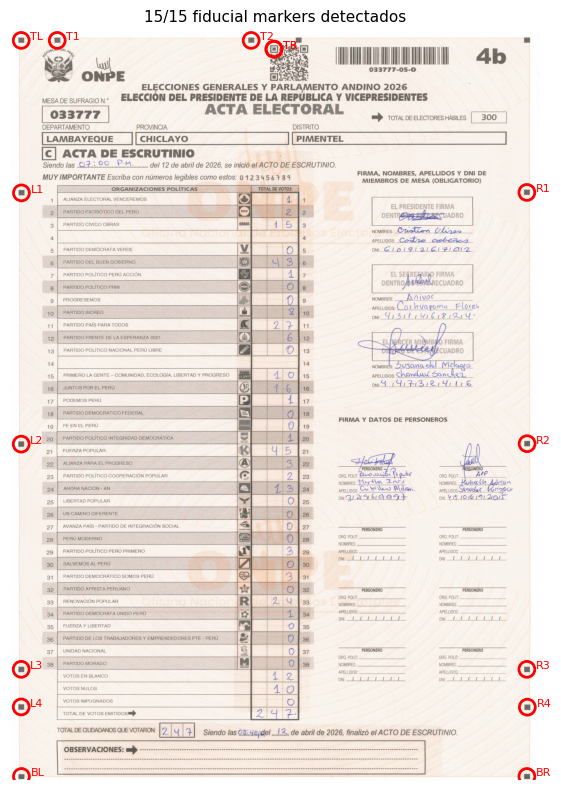

In [6]:
markers = detect_15(PNG_PATH)
print(f'detectados: {len(markers)}/15 markers')

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(img, cmap='gray')
for role, (x, y) in markers.items():
    ax.add_patch(plt.Circle((x, y), 35, color='red', fill=False, linewidth=2))
    ax.annotate(role, (x + 40, y), color='red', fontsize=8)
ax.set_title(f'{len(markers)}/15 fiducial markers detectados', fontsize=11)
ax.axis('off')
plt.tight_layout(); plt.show()

## Paso 3: Recorte por plantilla calibrada en 42 campos

`templates.json` define las cajas relativas `[x0, y0, x1, y1]` (en
`[0, 1]`) de los 42 campos del acta:
- 38 organizaciones politicas.
- 1 votos en blanco + 1 nulos + 1 impugnados + 1 total ciudadanos.

Si la deteccion recupera >=4 markers en >=3 zonas, se computa una afin
que corrige diferencias de escala/rotacion/traslacion entre actas.

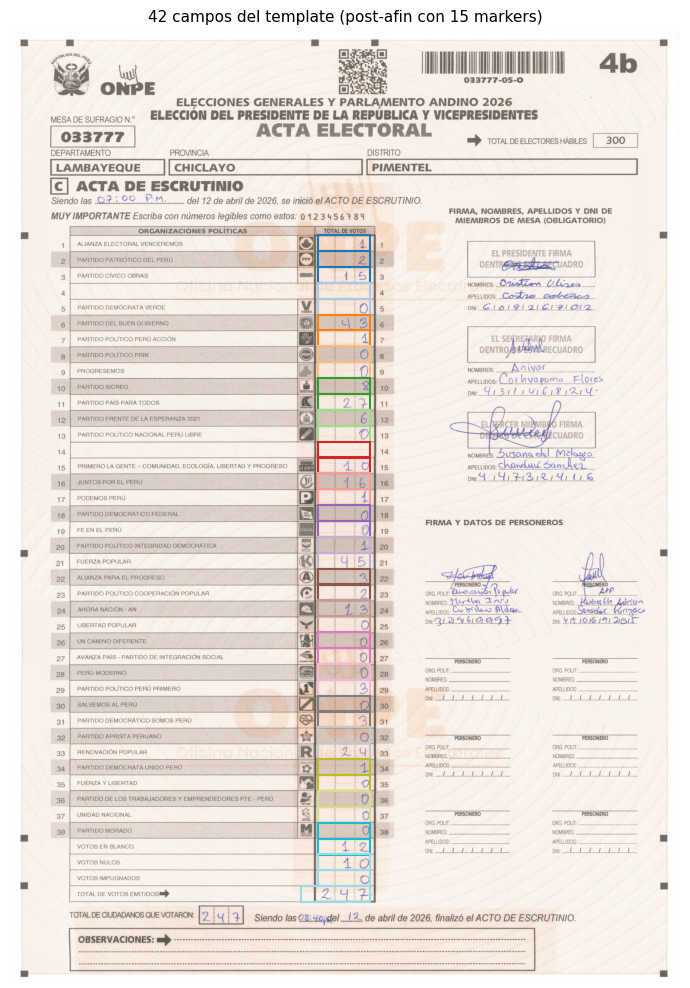

In [7]:
tmpl_aligned = transform_template(TEMPLATE, markers, ANCHORS, img.size)
w, h = img.size

fig, ax = plt.subplots(figsize=(7, 10))
ax.imshow(img, cmap='gray')
colors = plt.cm.tab20(np.linspace(0, 1, 42))
for color, f in zip(colors, tmpl_aligned['fields']):
    x0, y0, x1, y1 = f['box']
    rect = mpatches.Rectangle((x0 * w, y0 * h), (x1 - x0) * w, (y1 - y0) * h,
                              linewidth=1.5, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
ax.set_title(f'42 campos del template (post-afin con {len(markers)} markers)', fontsize=11)
ax.axis('off')
plt.tight_layout(); plt.show()

## Paso 4: Subdivision de cada campo en celdas

Cada campo se parte en `n_digits` celdas equiespaciadas (3 para
partidos y votos especiales, 4 para `total_ciudadanos`). Cada celda es
candidata a contener un digito manuscrito 0-9.

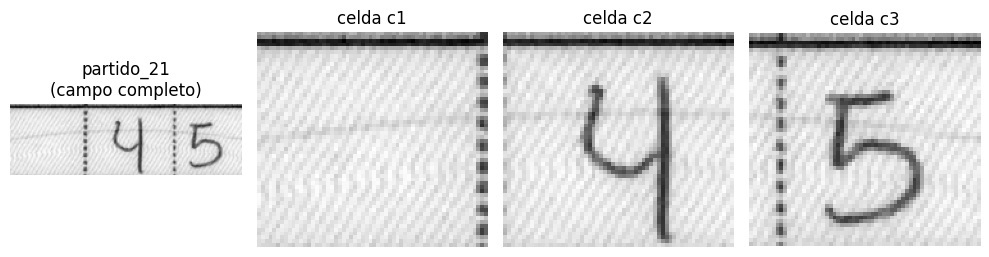

In [8]:
fields_crops = crop_fields(PNG_PATH, tmpl_aligned)
field_name = 'partido_21'
field_img = fields_crops[field_name]
n_cells = next(f['n_digits'] for f in TEMPLATE['fields'] if f['name'] == field_name)
cells = split_digits(field_img, n_cells)

fig, axes = plt.subplots(1, 1 + n_cells, figsize=(2.5 * (1 + n_cells), 2.5))
axes[0].imshow(field_img, cmap='gray'); axes[0].set_title(f'{field_name}\n(campo completo)')
axes[0].axis('off')
for i, c in enumerate(cells):
    axes[i + 1].imshow(c, cmap='gray')
    axes[i + 1].set_title(f'celda c{i+1}'); axes[i + 1].axis('off')
plt.tight_layout(); plt.show()

## Paso 5: Filtrado de celdas vacias por convencion right-justified

ONPE escribe las cifras alineadas a la derecha y deja en blanco las
celdas de la izquierda. `es_celda_escrita(value, n_cells, cell_position)`
retorna `True` si la celda DEBE contener un digito segun el valor real.

Ejemplos en un campo de 3 celdas:
- `value=5`   -> `[vacio, vacio, '5']`
- `value=18`  -> `[vacio, '1', '8']`
- `value=144` -> `['1', '4', '4']`
- `value=0`   -> `[vacio, vacio, vacio]` (no se escribe '000')

Esto descarta ~70% de las celdas (las vacias) del training set.

valor real del campo partido_21: 45
digitos right-justified: [0, 4, 5]


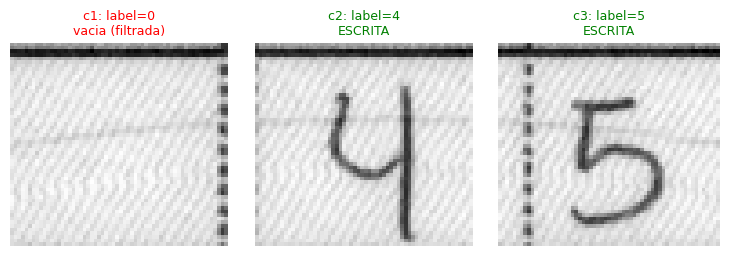

In [9]:
archivos = pd.read_parquet(REPO / 'data/labels/actas_archivos.parquet')
votos = pd.read_parquet(REPO / 'data/labels/actas_votos.parquet')
cabecera = pd.read_parquet(REPO / 'data/labels/actas_cabecera.parquet')
id_acta = int(archivos[archivos.archivoId == ARCHIVO_ID].iloc[0]['idActa'])
votos_acta = votos[votos.idActa == id_acta]
total_emit = int(cabecera[cabecera.idActa == id_acta].iloc[0]['totalVotosEmitidos'])
valor_real = field_value_for(field_name, votos_acta, total_emit)
labels = int_to_digits(valor_real, n_cells)
print(f'valor real del campo {field_name}: {valor_real}')
print(f'digitos right-justified: {labels}')

fig, axes = plt.subplots(1, n_cells, figsize=(2.5 * n_cells, 2.5))
for pos in range(n_cells):
    escrita = es_celda_escrita(valor_real, n_cells, pos)
    axes[pos].imshow(cells[pos], cmap='gray')
    title = f'c{pos+1}: label={labels[pos]}\n' + ('ESCRITA' if escrita else 'vacia (filtrada)')
    axes[pos].set_title(title, fontsize=9, color='red' if not escrita else 'green')
    axes[pos].axis('off')
plt.tight_layout(); plt.show()

## Paso 6: Dataset listo — manifest CSV

Aplicando los pasos 1-5 sobre 5,000 actas obtenemos 152,000 crops
32×32 etiquetados, distribuidos en 3 splits 70/15/15 por `archivoId`.

train: 106,123 crops

primeras 5 filas:
                                              path  label
0/69dc3b86d7b6147f63e587aa_total_ciudadanos_c2.png      0
      0/69dc3ca7d7b6147f63e587fb_partido_33_c2.png      0
0/69dc4d45d7b6147f63e59acf_total_ciudadanos_c2.png      0
     0/69dc4d50d7b6147f63e59aec_votos_nulos_c2.png      0
      0/69dc4fced7b6147f63e5a2d2_partido_03_c2.png      0


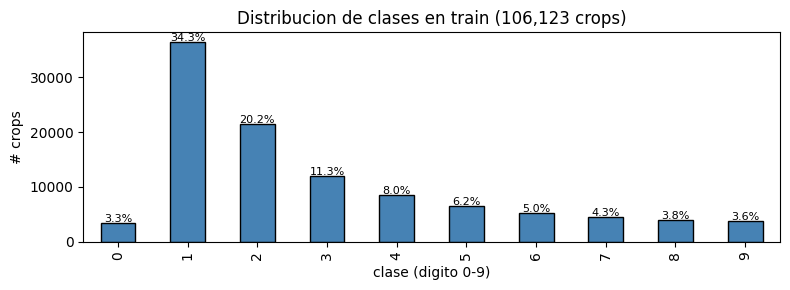

In [10]:
manifest = pd.read_csv(REPO / 'data/manifest_train.csv')
print(f'train: {len(manifest):,} crops')
print('\nprimeras 5 filas:')
print(manifest.head().to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
dist = manifest['label'].value_counts().sort_index()
dist.plot.bar(ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('clase (digito 0-9)'); ax.set_ylabel('# crops')
ax.set_title(f'Distribucion de clases en train ({len(manifest):,} crops)')
for c, v in dist.items():
    ax.text(c, v + 200, f'{100*v/len(manifest):.1f}%', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

## Paso 7: Entrenamiento — ResNet-18 estilo CIFAR (GPU)

**Modelo**: ResNet-18 (He et al., 2015) adaptada a entrada 1×32×32 con
skip connections, 11.17M parametros.

**Entrenamiento** (combinacion ganadora de ablations):
- Adam lr=5e-4, batch=128, 20 epochs.
- Label smoothing 0.1 + RandAugment + mixup α=0.2 + cosine LR.

Tiempo esperado: ~5-8 min en T4 GPU.

In [11]:
# Guard: restablecer CWD si el kernel se reinicio entre celdas
import os
if os.path.isdir('actas-cnn'):
    os.chdir('actas-cnn')

!python train.py --manifest data/manifest_train.csv --root data/crops_train \
                 --arch resnet18 --epochs 20 \
                 --label-smoothing 0.1 --randaugment \
                 --mixup 0.2 --cosine-lr \
                 --suffix colab_demo


epoch 01  train_acc 0.5475  val_acc 0.9658  lr 0.000500
epoch 02  train_acc 0.5790  val_acc 0.9699  lr 0.000497
epoch 03  train_acc 0.5702  val_acc 0.9741  lr 0.000488
epoch 04  train_acc 0.5654  val_acc 0.9763  lr 0.000473
epoch 05  train_acc 0.5890  val_acc 0.9779  lr 0.000452
epoch 06  train_acc 0.5827  val_acc 0.9801  lr 0.000427
epoch 07  train_acc 0.5863  val_acc 0.9808  lr 0.000397
epoch 08  train_acc 0.5589  val_acc 0.9796  lr 0.000363
epoch 09  train_acc 0.5949  val_acc 0.9816  lr 0.000327
epoch 10  train_acc 0.5656  val_acc 0.9822  lr 0.000289
epoch 11  train_acc 0.5809  val_acc 0.9810  lr 0.000250
epoch 12  train_acc 0.5796  val_acc 0.9833  lr 0.000211
epoch 13  train_acc 0.5807  val_acc 0.9826  lr 0.000173
epoch 14  train_acc 0.5941  val_acc 0.9827  lr 0.000137
epoch 15  train_acc 0.5852  val_acc 0.9828  lr 0.000103
epoch 16  train_acc 0.6164  val_acc 0.9831  lr 0.000073
epoch 17  train_acc 0.5974  val_acc 0.9830  lr 0.000048
epoch 18  train_acc 0.5815  val_acc 0.9840  lr 0

## Paso 8: Evaluacion downstream

`scripts/evaluate.py` mide:
- **Digit-level**: 1 crop correcto.
- **Field-level**: entero reconstruido coincide con valor real.
- **Acta-level**: los 42 campos correctos en simultaneo.
- **Reconstruccion del total agregado**: `sum(partidos + blanco + nulos +
  impugnados)` vs `totalVotosEmitidos`.

In [ ]:
# Guard: restablecer CWD si el kernel se reinicio entre celdas
import os
if os.path.isdir('actas-cnn'):
    os.chdir('actas-cnn')

!python scripts/evaluate.py --split val \
    --checkpoint checkpoints/resnet18_colab_demo_best.pt \
    --out-csv data/evaluate_val_colab_demo.csv


## Paso 9: Visualizaciones de error

In [ ]:
# Guard: restablecer CWD + REPO + imports core si el kernel se reinicio
import os, sys
from pathlib import Path
if os.path.isdir('actas-cnn'):
    os.chdir('actas-cnn')
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
REPO = Path.cwd()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

conf_png = REPO / 'data/visualizaciones/evaluate_confusion_val.png'
hist_png = REPO / 'data/visualizaciones/evaluate_error_hist_val.png'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(Image.open(conf_png)); axes[0].axis('off'); axes[0].set_title('Matriz de confusion')
axes[1].imshow(Image.open(hist_png)); axes[1].axis('off'); axes[1].set_title('Distribucion de error del total')
plt.tight_layout(); plt.show()

worst = pd.read_csv(REPO / 'data/evaluate_worst20_val.csv').head(5)
print('Top 5 actas peor reconstruidas:')
print(worst[['archivoId', 'total_pred', 'total_real', 'error_total', 'n_fields_wrong']].to_string(index=False))


## Paso 10: Bajar resultados al navegador

Descarga el checkpoint `.pt` (~45 MB) y el CSV de evaluate (~3 MB) a
tu carpeta Downloads local. Despues movelos al repo local:

```bash
mv ~/Downloads/resnet18_colab_demo_best.pt checkpoints/
mv ~/Downloads/evaluate_val_colab_demo.csv data/
```

In [ ]:
# Guard: restablecer CWD si el kernel se reinicio entre celdas
import os
if os.path.isdir('actas-cnn'):
    os.chdir('actas-cnn')

ckpt = 'checkpoints/resnet18_colab_demo_best.pt'
csv = 'data/evaluate_val_colab_demo.csv'
try:
    from google.colab import files
    files.download(ckpt)
    files.download(csv)
    print('descargados al navegador')
except ImportError:
    print(f'archivos en VM (bajar manualmente):\n  {ckpt}\n  {csv}')


## Cierre — Resumen

Pipeline reproducido en GPU. Metricas esperadas (val set, 693 actas):

| Metrica | Valor |
|---|---|
| Digit-level accuracy | ~98.12% |
| Field-level accuracy | ~98.87% |
| **Acta-level (42 campos correctos)** | **~90.33%** |
| **Reconstruccion exacta del total agregado** | **~93.80%** |
| MAE del total agregado | ~2.40 votos |

### Referencias
- **Datos**: Oficina Nacional de Procesos Electorales (ONPE), Peru.
- **Arquitectura**: He, K., Zhang, X., Ren, S., & Sun, J. (2015).
  *Deep Residual Learning for Image Recognition*. arXiv:1512.03385.